# Fitness Trainer
Authors: Georg and Martina

## Imports

In [ ]:

import pandas as pd
import numpy as np
import os

# machine learning: preprocessing, models, evaluation
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to export the model(s)
import joblib

# ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## Data pre-processing

Raw sensor data from CSV files is loaded and organized into four groups based on sampling rate and device placement. Before feature extraction, three pre-processing steps are applied:

1. **Gyroscope unit normalization**: as pointed out in the Discord group chat, some devices record gyroscope data in degrees/s, others in rad/s. All data is converted to rad/s for consistency.
2. **NaN removal**: any rows with missing sensor values are dropped.
3. **Timestamp normalization**: timestamps are shifted to start at 0 for each recording, making them comparable across sessions.

### Load raw data

In [ ]:
data_folder = 'data'

# walk through the data folder and collect all CSV file paths
all_csv_paths = []
for dirpath, dirnames, filenames in os.walk(data_folder):
    for filename in filenames:
        if filename.endswith('.csv'):
            all_csv_paths.append((os.path.join(dirpath, filename), filename))

# map activity names in filenames to integer labels
# (required by sklearn classifiers)
ACTIVITY_LABELS = {
    'running': 0,
    'rowing': 1,
    'jumpingjacks': 2,
    'lifting': 3
}

# helper function to read CSV files into DataFrames and assign activity labels based on filename
def make_df_list(csv_paths, keyword):
    dfs = []
    for full_path, filename in csv_paths:
        if keyword in filename:
            df = pd.read_csv(full_path)
            for activity, label in ACTIVITY_LABELS.items():
                if activity in filename:
                    df['activity_label'] = label
                    break
            dfs.append(df)
    return dfs

# create separate lists of DataFrames for each freq × placement combination
dfs_20Hz_hand   = make_df_list(all_csv_paths, '20Hz-hand')
dfs_20Hz_pocket = make_df_list(all_csv_paths, '20Hz-pocket')
dfs_100Hz_hand  = make_df_list(all_csv_paths, '100Hz-hand')
dfs_100Hz_pocket = make_df_list(all_csv_paths, '100Hz-pocket')

# store all lists in a dictionary for easy access later
all_df_lists = {
    '20Hz_hand':    dfs_20Hz_hand,
    '20Hz_pocket':  dfs_20Hz_pocket,
    '100Hz_hand':   dfs_100Hz_hand,
    '100Hz_pocket': dfs_100Hz_pocket
}

#### Check how the dataset looks like

In [ ]:
# check the number of dataframes in each list to verify that they were read correctly
print("Number of dataframes in dfs_20Hz_hand:", len(dfs_20Hz_hand))
print("Number of dataframes in dfs_20Hz_pocket:", len(dfs_20Hz_pocket))
print("Number of dataframes in dfs_100Hz_hand:", len(dfs_100Hz_hand))
print("Number of dataframes in dfs_100Hz_pocket:", len(dfs_100Hz_pocket))

Number of dataframes in dfs_20Hz_hand: 212
Number of dataframes in dfs_20Hz_pocket: 190
Number of dataframes in dfs_100Hz_hand: 191
Number of dataframes in dfs_100Hz_pocket: 190


Total CSV files found: 843

       Group  Freq Placement  Recordings  Total samples  running  rowing  jumpingjacks  lifting
   20Hz_hand  20Hz      hand         212          40413       72      45            50       45
 20Hz_pocket  20Hz    pocket         190          36891       50      45            50       45
  100Hz_hand 100Hz      hand         191         175040       50      45            51       45
100Hz_pocket 100Hz    pocket         190         173871       50      45            50       45


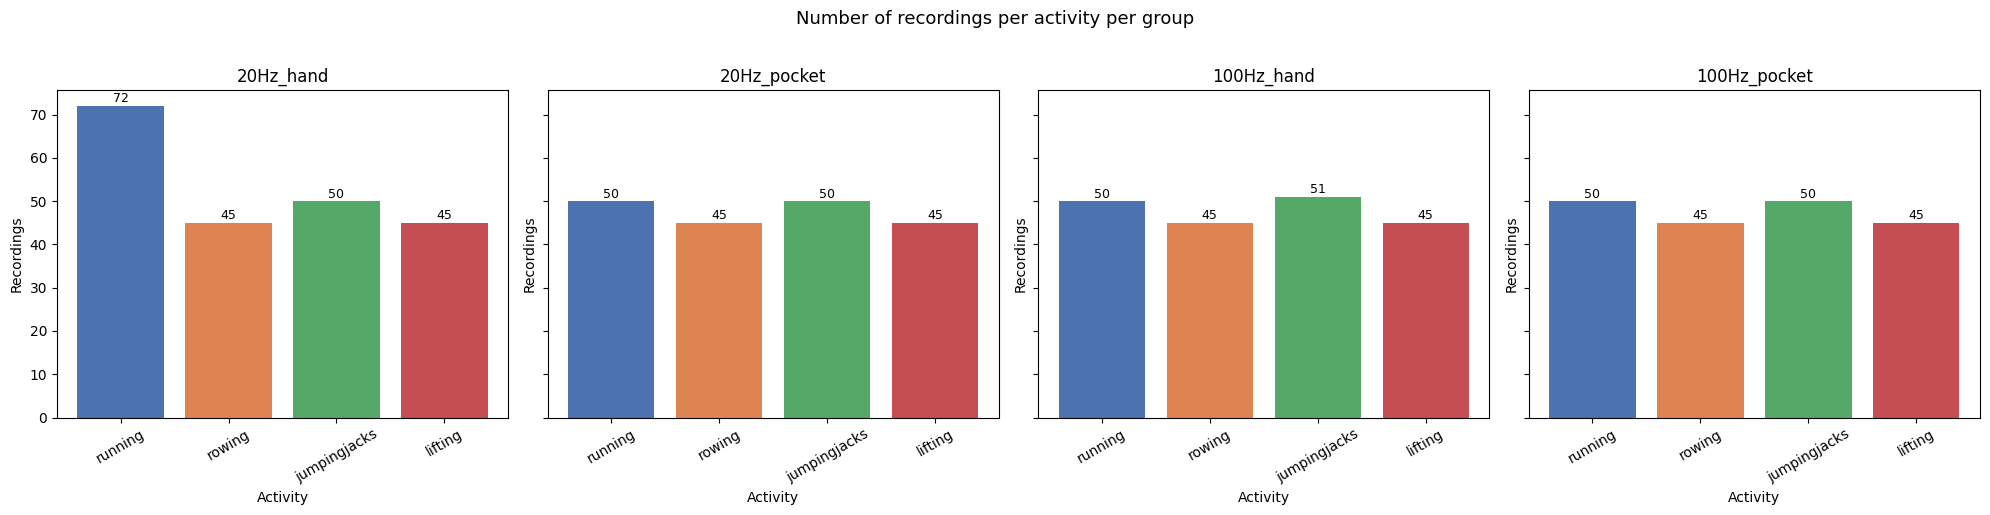

In [ ]:
# NOTE: this plot was created with the help of AI

label_names = {v: k for k, v in ACTIVITY_LABELS.items()}

print(f"Total CSV files found: {len(all_csv_paths)}\n")

rows = []
for group, dfs in all_df_lists.items():
    freq, placement = group.split('_')
    counts = {name: 0 for name in ACTIVITY_LABELS}
    total_samples = 0
    for df in dfs:
        label = int(df['activity_label'].iloc[0])
        counts[label_names[label]] += 1
        total_samples += len(df)
    rows.append({
        'Group': group,
        'Freq': freq,
        'Placement': placement,
        'Recordings': len(dfs),
        'Total samples': total_samples,
        **{name: counts[name] for name in ACTIVITY_LABELS}
    })

overview = pd.DataFrame(rows)
print(overview.to_string(index=False))

# bar chart: number of recordings per activity per group
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, (_, row) in zip(axes, overview.iterrows()):
    activity_counts = [row[name] for name in ACTIVITY_LABELS]
    bars = ax.bar(list(ACTIVITY_LABELS.keys()), activity_counts,
                  color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    ax.set_title(row['Group'])
    ax.set_xlabel('Activity')
    ax.set_ylabel('Recordings')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, activity_counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Number of recordings per activity per group', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Dataset observations:**

The dataset was collected by 10 participants. Each participant recorded 5 repetitions per activity, 
per sampling rate, and per placement, yielding an expected baseline of:
4 activities × 2 frequencies × 2 placements × 5 repetitions × 10 participants = **800 recordings total**.

The distribution is largely balanced across groups and activities (~45–51 recordings each), 
with one exception: `running` in the `20Hz_hand` group contains 72 recordings instead of the 
expected ~50. This is because one participant (Daniel) recorded additional sessions for that 
activity/configuration combination.

### Gyroscope unit normalization

We noticed that some DIPPID devices report gyroscope values in degrees/s while others use rad/s. Since the magnitude of the signal differs drastically between units (degrees/s values typically exceed 100), we detect the unit automatically and convert to rad/s where needed.

In [ ]:
# function to check if gyro data is in radians or degrees
def radian_or_degree(df):
    for col in df.columns:
        if 'gyro' in col:
            if df[col].abs().max() > 100:       # the 100 threshold was selected after observing the data ourselves
                return 'degree'
    return 'radian'

# function to convert gyro data from degrees to radians
def degree_to_radian(df):
    for col in df.columns:
        if 'gyro' in col:
            df[col] = np.deg2rad(df[col])
    return df

In [ ]:
# convert all gyro data to radians if needed
for dfs in all_df_lists.values():
    for df in dfs:
        if radian_or_degree(df) == 'degree':
            degree_to_radian(df)

### Removing NaN values


Rows containing NaN in any sensor column are dropped, to be safe.

In [ ]:
# drop any rows with NaN values (if any)
for key, dfs in all_df_lists.items():
    all_df_lists[key] = [df.dropna() for df in dfs]

### Modify timestamps to start at 0s

To make recordings comparable and easier to read, we subtract the minimum timestamp from each recording so that all sessions start at t=0. 

In [ ]:
# create separate lists to hold the timestamp-normalized dataframes
ts_normalized_20Hz_hand = []
ts_normalized_20Hz_pocket = []
ts_normalized_100Hz_hand = []
ts_normalized_100Hz_pocket = []

# create a dictionary to hold the timestamp-normalized dataframes for easy access
all_timestamp_normalized_dfs = {
    '20Hz_hand': ts_normalized_20Hz_hand,
    '20Hz_pocket': ts_normalized_20Hz_pocket,
    '100Hz_hand': ts_normalized_100Hz_hand,
    '100Hz_pocket': ts_normalized_100Hz_pocket
}

# from each row in the timestamp column in each dataframe, the minimum timestamp is subtracted 
for key, dfs in all_df_lists.items():
    for df in dfs:
        min_timestamp = df['timestamp'].min()
        df_tmp = df.copy()
        df_tmp['timestamp'] = (df_tmp['timestamp'] - min_timestamp)
        all_timestamp_normalized_dfs[key].append(df_tmp)

In [ ]:
# verify timestamp normalization: first recording of 20Hz_hand should start at 0
sample_df = all_timestamp_normalized_dfs['20Hz_hand'][0]
print("First 3 rows after timestamp normalization:")
print(sample_df.head(3).to_string(index=False))
print(f"\nTimestamp range: {sample_df['timestamp'].min():.4f}s → {sample_df['timestamp'].max():.4f}s")
print(f"Duration: {sample_df['timestamp'].max():.2f}s | Samples: {len(sample_df)}")

First 3 rows after timestamp normalization:
 id  timestamp     acc_x     acc_y     acc_z    gyro_x    gyro_y   gyro_z  activity_label
  1   0.000000 -6.207352  1.385513 -1.728902 -0.395213  0.096939 2.800580               2
  2   0.062567 -3.385806 -0.283595  1.610046 -3.393400 -4.149738 4.316984               2
  3   0.128285 -2.509397 -1.178308  1.921707  0.048470 -4.837366 5.885586               2

Timestamp range: 0.0000s → 9.9302s
Duration: 9.93s | Samples: 160


## Feature extraction

Raw sensor signals are not fed directly to the classifier. Instead, we extract a compact set of descriptive features from fixed-length windows of the signal. This reduces dimensionality while retaining the most informative signal characteristics, and enables real-time prediction: the classifier operates on one window at a time, without needing the full recording history.

The extraction pipeline follows these steps: segment each recording into overlapping windows → compute magnitude channels → extract features per window → split at recording level → build feature DataFrames → scale features.

### Windowing

We segment each recording into overlapping windows of fixed duration, where each window becomes one independent sample for the classifier.

We use 2-second windows. This window length was selecteed initially because it is a time we thought would be enough to capture at least one full movement cycle for all four activities. We also use 50% overlap to increase the number of training samples without recording more data.

The train-test split (80/20) is done at the recording level, not the window level. We initially split by window, which we later realized causes data leakage: windows from the same recording end up in both sets, artificially inflating accuracy since consecutive windows are highly correlated.

We select 80/20 because it's the most common ratio. 

We try different window lengths, overlap ratios and train-test split ratios later.

In [ ]:
window_size_seconds = 2  # duration of each window in seconds

# number of samples per window at each sampling rate
WINDOW_SIZE_20HZ  = window_size_seconds * 20   # = 40 samples
WINDOW_SIZE_100HZ = window_size_seconds * 100  # = 200 samples

OVERLAP = 0.5  # 50% overlap between consecutive windows

In [ ]:
# function to create overlapping windows from a dataframe
def get_windows(df, window_size):
    step = int(window_size * (1 - OVERLAP))
    windows = []
    for start in range(0, len(df) - window_size + 1, step):
        window = df.iloc[start:start + window_size]
        windows.append(window)
    return windows

### Feature set

For each window, we extract features from 8 signal channels:
`acc_x`, `acc_y`, `acc_z`, `gyro_x`, `gyro_y`, `gyro_z`, `acc_magnitude`, `gyro_magnitude`

The magnitude channels are derived as the Euclidean norm of the three axes and capture overall movement intensity *independent of device orientation*.

**Per-channel features (4 × 8 = 32 features):**

- **`max`**: Peak signal amplitude. We thought this feature would be useful for distinguishing high-impact activities 
  (jumping jacks, running) from low-impact ones (lifting, rowing), where 
  accelerations remain moderate throughout.

- **`median`**: Robust central tendency of the signal. At first, we though about using the mean, but since this metric is less sensitive to outliers (which we didn't manage before), we choose it, hoping to get a stable estimate of the "typical" signal level during the window.

- **`std`**: Signal variability. Intuitively, we thought that rhythmic and explosive activities like jumping jacks 
  would produce high variability, while controlled movements like lifting would tend to be more stable.

- **`dominant_freq`**: The frequency of the strongest component in the FFT spectrum 
  (excluding DC component - this we found out after testing, he). Encodes movement cadence; for example, running usually has a higher stride 
  frequency than rowing, making this feature useful for separating activities with 
  different rhythms.

**Cross-axis correlation features (6 features):**

We compute the Pearson correlations between axis pairs:
`acc_x_y`, `acc_x_z`, `acc_y_z`, `gyro_x_y`, `gyro_x_z`, `gyro_y_z`

These were added after initial experiments with only the per-channel features did not yield 
satisfactory results. This was particularly noticeable for distinguishing rowing from lifting, which share similar 
intensity levels but happen in different movement planes. We consulted AI about ways to capture 
3D movement structure, which suggested cross-axis correlations. The idea made sense to us: 
rowing (horizontal) and lifting (vertical) should differ in how their axes move relative to 
each other.

One known limitation is that these features depend on how the device is held. We accepted 
this trade-off assuming most users hold their phone similarly to how we did when collecting 
the dataset.

**Total: 38 features per window.**

In [ ]:
cols_to_evaluate = [
    'acc_x', 'acc_y', 'acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'acc_magnitude', 'gyro_magnitude'
]

# function to compute the dominant frequency of a signal using FFT
def get_dominant_frequency(series, sampling_rate):
    n = len(series)
    freqs = np.fft.rfftfreq(n, d=1/sampling_rate)
    fft_magnitude = np.abs(np.fft.rfft(series))
    return freqs[1:][np.argmax(fft_magnitude[1:])]

# function to compute correlation between two signal axes in a window
def get_correlation(window, col1, col2):
    corr = window[col1].corr(window[col2])
    return corr if not np.isnan(corr) else 0.0

# function to extract features from a single window dataframe
def extract_features_from_window(window, sampling_rate):
    window = window.copy()
    # compute magnitude channels before feature extraction
    window['acc_magnitude']  = np.sqrt(window['acc_x']**2 + window['acc_y']**2 + window['acc_z']**2)
    window['gyro_magnitude'] = np.sqrt(window['gyro_x']**2 + window['gyro_y']**2 + window['gyro_z']**2)

    features = {'activity_label': window['activity_label'].iloc[0]}

    # extract features per channel
    for col in cols_to_evaluate:
        features[f'{col}_max']           = window[col].max()
        features[f'{col}_median']        = window[col].median()
        features[f'{col}_std']           = window[col].std()
        features[f'{col}_dominant_freq'] = get_dominant_frequency(window[col], sampling_rate)

    # cross-axis correlations
    features['acc_x_y_corr']  = get_correlation(window, 'acc_x',  'acc_y')
    features['acc_x_z_corr']  = get_correlation(window, 'acc_x',  'acc_z')
    features['acc_y_z_corr']  = get_correlation(window, 'acc_y',  'acc_z')
    features['gyro_x_y_corr'] = get_correlation(window, 'gyro_x', 'gyro_y')
    features['gyro_x_z_corr'] = get_correlation(window, 'gyro_x', 'gyro_z')
    features['gyro_y_z_corr'] = get_correlation(window, 'gyro_y', 'gyro_z')

    return features

In [ ]:
def build_feature_df(dfs, window_size, sampling_rate):
    all_features = []
    for df in dfs:
        windows = get_windows(df, window_size)
        for window in windows:
            feats = extract_features_from_window(window, sampling_rate)
            all_features.append(feats)
    return pd.DataFrame(all_features)

# split by recording, not by window
splits = {}
for key, dfs in all_timestamp_normalized_dfs.items():
    sampling_rate = 20 if '20Hz' in key else 100
    window_size = WINDOW_SIZE_20HZ if '20Hz' in key else WINDOW_SIZE_100HZ

    # 80/20 split with a fixed random seed for reproducibility
    train_dfs, test_dfs = train_test_split(dfs, test_size=0.2, random_state=42)

    train_df = build_feature_df(train_dfs, window_size, sampling_rate)
    test_df  = build_feature_df(test_dfs,  window_size, sampling_rate)

    # print train-test sets sizes
    splits[key] = {'train': train_df, 'test': test_df}
    print(f"{key}: {len(train_df)} train windows, {len(test_df)} test windows")


20Hz_hand: 1425 train windows, 369 test windows
20Hz_pocket: 1315 train windows, 324 test windows
100Hz_hand: 1205 train windows, 295 test windows
100Hz_pocket: 1207 train windows, 286 test windows


**Note on feature set:**

We use all 38 features without performing formal feature selection. This is because in practice, the models achieved strong accuracy with the full set, so we did not see a need to reduce it. 

However, a more standard approach would involve testing feature importance or running a selection method to identify which features contribute most. This could reduce computational cost at inference time, which matters for real-time prediction on a mobile device, and might also improve generalization by removing noisy or redundant features.

## Trying out different models

### Kernel and OvR/OvO comparison

We start by comparing four SVM kernels (`linear`, `rbf`, `poly`, `sigmoid`) across all four frequency-placement groups, combined with both multiclass strategies (One vs. One and One vs. Rest), before tuning anything else.

In [ ]:
# kernels to compare
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

# strategies to compare
strategies = {'OvR': OneVsRestClassifier, 'OvO': OneVsOneClassifier}

kernel_results = {}

# train and evaluate models for each group, kernel, and strategy
for key, split in splits.items():
    X_train = split["train"].drop(columns=["activity_label"])
    y_train = split["train"]["activity_label"]
    X_test  = split["test"].drop(columns=["activity_label"])
    y_test  = split["test"]["activity_label"]

    kernel_results[key] = {s: [] for s in strategies}

    for kernel in kernels:
        for strat_name, strat_cls in strategies.items():
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", strat_cls(SVC(kernel=kernel)))
            ])
            model.fit(X_train, y_train)
            acc = accuracy_score(y_test, model.predict(X_test))
            kernel_results[key][strat_name].append(acc)

    print(f"\n{key}:")
    print(f"  {'kernel':<10} {'OvR':>6} {'OvO':>6}")
    for i, kernel in enumerate(kernels):
        ovr = kernel_results[key]['OvR'][i]
        ovo = kernel_results[key]['OvO'][i]
        print(f"  {kernel:<10} {ovr:>6.3f} {ovo:>6.3f}")



20Hz_hand:
  kernel        OvR    OvO
  linear      0.970  0.984
  rbf         0.981  0.981
  poly        0.970  0.957
  sigmoid     0.802  0.821

20Hz_pocket:
  kernel        OvR    OvO
  linear      0.889  0.951
  rbf         0.898  0.907
  poly        0.880  0.870
  sigmoid     0.654  0.713

100Hz_hand:
  kernel        OvR    OvO
  linear      0.885  0.895
  rbf         0.969  0.983
  poly        0.956  0.969
  sigmoid     0.715  0.732

100Hz_pocket:
  kernel        OvR    OvO
  linear      0.913  0.906
  rbf         0.941  0.937
  poly        0.850  0.857
  sigmoid     0.612  0.713


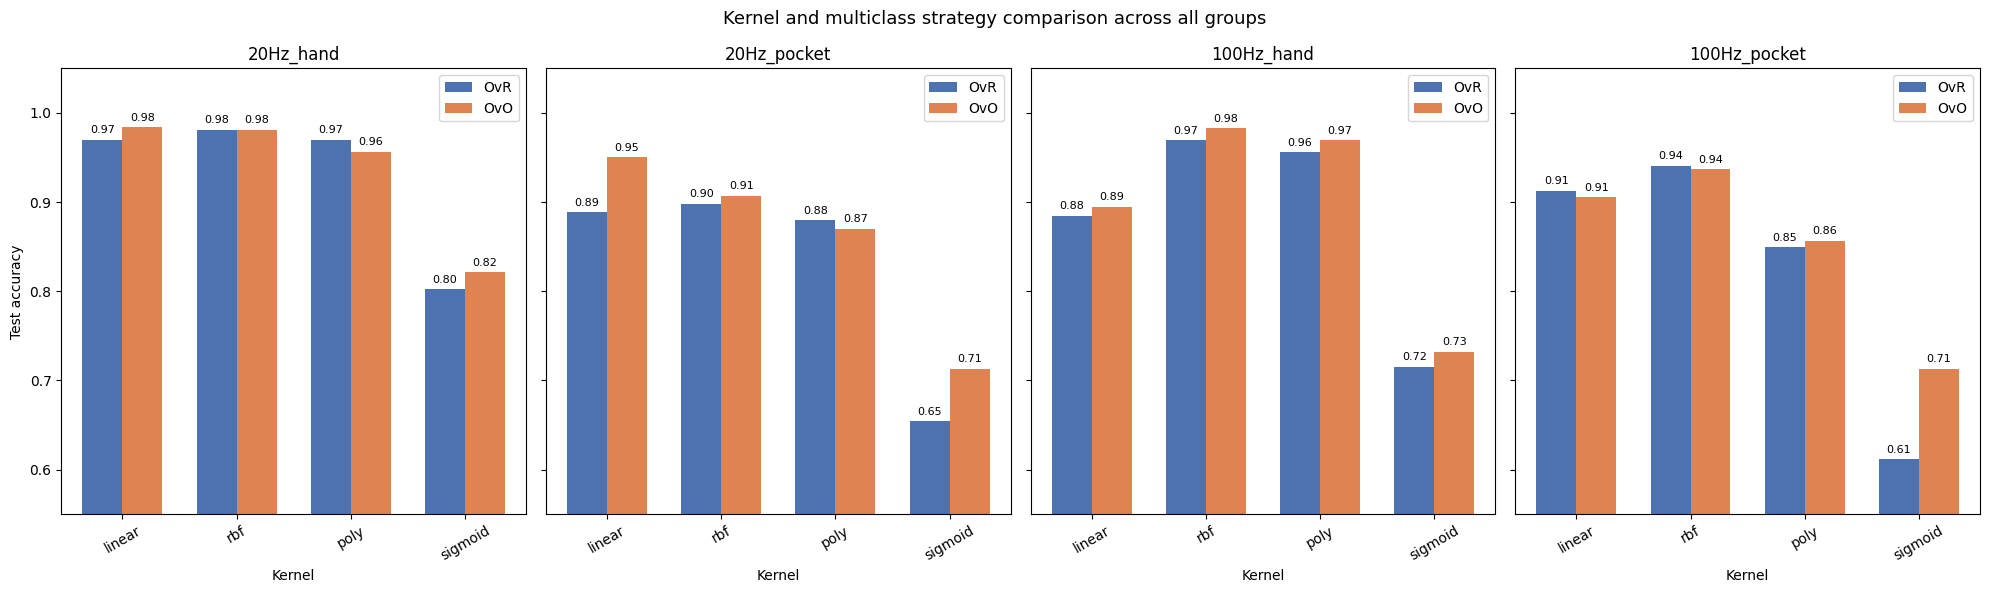

In [ ]:
# NOTE: this plot was created with the help of AI

# plot the results in a grouped bar char
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
x = np.arange(len(kernels))
width = 0.35

for ax, (key, results) in zip(axes, kernel_results.items()):
    bars_ovr = ax.bar(x - width/2, results['OvR'], width, label='OvR', color='#4C72B0')
    bars_ovo = ax.bar(x + width/2, results['OvO'], width, label='OvO', color='#DD8452')
    ax.set_title(key)
    ax.set_ylim(0.55, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(kernels, rotation=30)
    ax.set_xlabel('Kernel')
    ax.legend()
    for bar in list(bars_ovr) + list(bars_ovo):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel('Test accuracy')
plt.suptitle('Kernel and multiclass strategy comparison across all groups', fontsize=13)
plt.tight_layout()
plt.show()

**Results:**

`linear`, `rbf`, and `poly` perform consistently well (0.88–0.98) across all groups, while `sigmoid` drops significantly (0.61–0.73). `rbf` is the most consistent overall.

OvO edges out OvR slightly in most cases, but differences are minimal (0–0.02). Since we use `predict_proba` to threshold prediction confidence in the final app, and OvR supports it while OvO does not, we go with **OvR + rbf** as the baseline for remaining comparisons.

### Windowing and split comparison

With OvR + rbf fixed, we validate our initial assumptions about window size, overlap, and train-test split ratio. We run these comparisons on `100Hz_hand` only to get a general idea, accepting that results might vary across groups.

In [ ]:
# shared setup for windowing comparisons
# uses OvR + rbf to match the chosen baseline from kernel comparison

COMPARISON_DFS = all_timestamp_normalized_dfs['100Hz_hand']
SAMPLING_RATE  = 100

def run_windowing_comparison(dfs, window_size, overlap, test_size):
    step = int(window_size * (1 - overlap))

    def get_windows_custom(df):
        return [df.iloc[s:s+window_size] for s in range(0, len(df)-window_size+1, step)]

    def build_df(dfs_list):
        all_feats = []
        for df in dfs_list:
            for w in get_windows_custom(df):
                all_feats.append(extract_features_from_window(w, SAMPLING_RATE))
        return pd.DataFrame(all_feats)

    train_dfs, test_dfs = train_test_split(dfs, test_size=test_size, random_state=42)
    X_train = build_df(train_dfs); y_train = X_train.pop('activity_label')
    X_test  = build_df(test_dfs);  y_test  = X_test.pop('activity_label')

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', OneVsRestClassifier(SVC(kernel='rbf')))
    ])
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

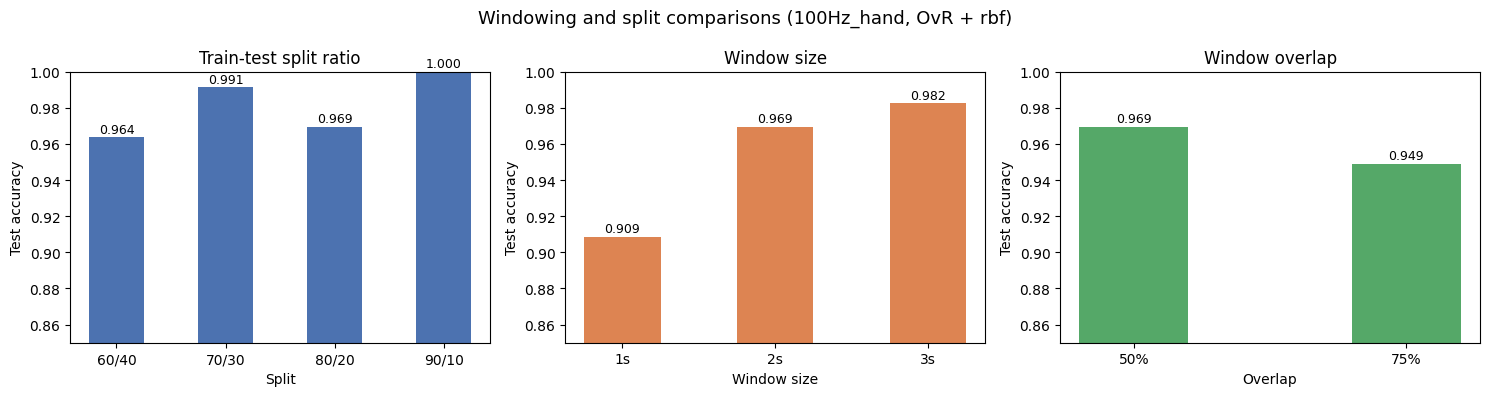

In [ ]:
# NOTE: this plot was created with the help of AI

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
y_min = 0.85

# 1. train-test split
split_ratios = [0.4, 0.3, 0.2, 0.1]
split_labels = ['60/40', '70/30', '80/20', '90/10']
split_accs = []
for ratio in split_ratios:
    acc = run_windowing_comparison(COMPARISON_DFS, window_size=200, overlap=0.5, test_size=ratio)
    split_accs.append(acc)

axes[0].bar(split_labels, split_accs, color='#4C72B0', width=0.5)
axes[0].set_ylim(y_min, 1)
axes[0].set_title('Train-test split ratio')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Test accuracy')
for i, acc in enumerate(split_accs):
    axes[0].text(i, acc + 0.001, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

# 2. window size
window_sizes_s = [1, 2, 3]
window_accs = []
for ws in window_sizes_s:
    acc = run_windowing_comparison(COMPARISON_DFS, window_size=ws*100, overlap=0.5, test_size=0.2)
    window_accs.append(acc)

axes[1].bar([f'{w}s' for w in window_sizes_s], window_accs, color='#DD8452', width=0.5)
axes[1].set_ylim(y_min, 1)
axes[1].set_title('Window size')
axes[1].set_xlabel('Window size')
axes[1].set_ylabel('Test accuracy')
for i, acc in enumerate(window_accs):
    axes[1].text(i, acc + 0.001, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

# 3. window overlap
overlaps = [0.5, 0.75]
overlap_labels = ['50%', '75%']
overlap_accs = []
for ov in overlaps:
    acc = run_windowing_comparison(COMPARISON_DFS, window_size=200, overlap=ov, test_size=0.2)
    overlap_accs.append(acc)

axes[2].bar(overlap_labels, overlap_accs, color='#55A868', width=0.4)
axes[2].set_ylim(y_min, 1)
axes[2].set_title('Window overlap')
axes[2].set_xlabel('Overlap')
axes[2].set_ylabel('Test accuracy')
for i, acc in enumerate(overlap_accs):
    axes[2].text(i, acc + 0.001, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Windowing and split comparisons (100Hz_hand, OvR + rbf)', fontsize=13)
plt.tight_layout()
plt.show()

**Results:**

Differences are small across the board, which suggests the model is fairly robust to these choices.

For the **split**, accuracy increases with more training data, but 90/10 leaves too few recordings for a reliable evaluation, so we stick with **80/20**.

For **window size**, 1s performs worse than the other two; we think this is because it is too short to capture a full movement cycle for slower activities like rowing. 2s and 3s are nearly identical, so we keep **2s** since shorter windows mean more responsive predictions in the app.

For **overlap**, 50% slightly outperforms 75%, so we stick with **50%**.

### Scaler comparison


We scale the extracted features inside the model Pipeline, which ensures the scaler is fit only on the training windows and applied to the test windows. We initially tried scaling the raw sensor signals before windowing, but this caused data leakage: the scaler was fit on the full recording, including test data.

StandardScaler (zero mean, unit variance) 
was our default assumption, but MinMaxScaler (scales to [0,1]) is also commonly used. 
We try both individually and combined (MinMax followed by Standard) to see if it makes 
a difference.

In [ ]:
# scalers to compare
scalers = {
    'StandardScaler': [('scaler', StandardScaler())],
    'MinMaxScaler':   [('scaler', MinMaxScaler())],
    'MinMax + Standard': [('minmax', MinMaxScaler()), ('standard', StandardScaler())],
}

scaler_results = {}

# train and evaluate models for each scaler
for scaler_name, scaler_steps in scalers.items():
    train_dfs, test_dfs = train_test_split(COMPARISON_DFS, test_size=0.2, random_state=42)

    def build_df(dfs_list):
        all_feats = []
        for df in dfs_list:
            windows = get_windows(df, WINDOW_SIZE_100HZ)
            for w in windows:
                all_feats.append(extract_features_from_window(w, SAMPLING_RATE))
        return pd.DataFrame(all_feats)

    X_train = build_df(train_dfs); y_train = X_train.pop('activity_label')
    X_test  = build_df(test_dfs);  y_test  = X_test.pop('activity_label')

    model = Pipeline(scaler_steps + [('clf', OneVsOneClassifier(SVC(kernel='rbf')))])
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    scaler_results[scaler_name] = acc
    print(f"  {scaler_name:<25} {acc:.3f}")

  StandardScaler            0.983
  MinMaxScaler              0.939
  MinMax + Standard         0.983


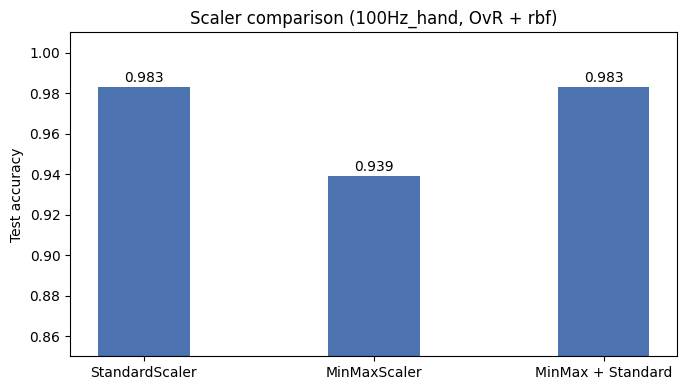

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(scaler_results.keys(), scaler_results.values(), color='#4C72B0', width=0.4)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel('Test accuracy')
ax.set_title('Scaler comparison (100Hz_hand, OvR + rbf)')
for bar, acc in zip(bars, scaler_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.001,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

**Results:**

StandardScaler and MinMax + Standard both hit 0.983, while MinMaxScaler alone drops 
to 0.939. This could have to do with features being centered around zero, which MinMaxScaler alone doesn't guarantee. 
We stick with **StandardScaler** since it's simpler and performs just as well.

### Hyperparameter tuning (GridSearch)


With OvR + rbf and StandardScaler fixed, we tune the remaining SVM hyperparameters `C` and `gamma` using GridSearch. We also include `poly` in the kernel search to keep the door open, since it performed well in the initial comparison.

In [ ]:
param_grid = {
    "clf__estimator__C":      [0.1, 1, 10, 100],
    "clf__estimator__gamma":  ["scale", "auto", 0.01, 0.001],
    "clf__estimator__kernel": ["rbf", "poly"]
}

grid_results = {}

for key, split in splits.items():
    X_train = split["train"].drop(columns=["activity_label"])
    y_train = split["train"]["activity_label"]
    X_test  = split["test"].drop(columns=["activity_label"])
    y_test  = split["test"]["activity_label"]

    base_model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", OneVsRestClassifier(SVC()))
    ])

    grid = GridSearchCV(base_model, param_grid, cv=5, n_jobs=-1)
    grid.fit(X_train, y_train)
    acc = accuracy_score(y_test, grid.predict(X_test))

    grid_results[key] = {'best_params': grid.best_params_, 'accuracy': acc}

    print(f"\n{key}:")
    print(f"  best params: {grid.best_params_}")
    print(f"  accuracy:    {acc:.3f}")


20Hz_hand:
  best params: {'clf__estimator__C': 10, 'clf__estimator__gamma': 'scale', 'clf__estimator__kernel': 'rbf'}
  accuracy:    0.986

20Hz_pocket:
  best params: {'clf__estimator__C': 10, 'clf__estimator__gamma': 0.01, 'clf__estimator__kernel': 'rbf'}
  accuracy:    0.938

100Hz_hand:
  best params: {'clf__estimator__C': 10, 'clf__estimator__gamma': 'scale', 'clf__estimator__kernel': 'rbf'}
  accuracy:    0.956

100Hz_pocket:
  best params: {'clf__estimator__C': 10, 'clf__estimator__gamma': 'scale', 'clf__estimator__kernel': 'rbf'}
  accuracy:    0.944


**Results:**

`rbf` wins across all four groups, confirming our earlier choice. `C=10` is the most common best value, with `100Hz_pocket` needing a higher `C=100` to fit its more variable data. `gamma` varies between `scale` and `0.01` depending on the group.

Interestingly, `20Hz_hand` achieves the highest accuracy, while the 100Hz groups land slightly lower, which we did not expect.

These best parameters are used to train the final models in the next step.

### Confusion matrices

We train one model per group using the best parameters found by GridSearch and plot 
the confusion matrix on the held-out test set. This lets us see not just overall accuracy 
but exactly which activities get confused with each other.

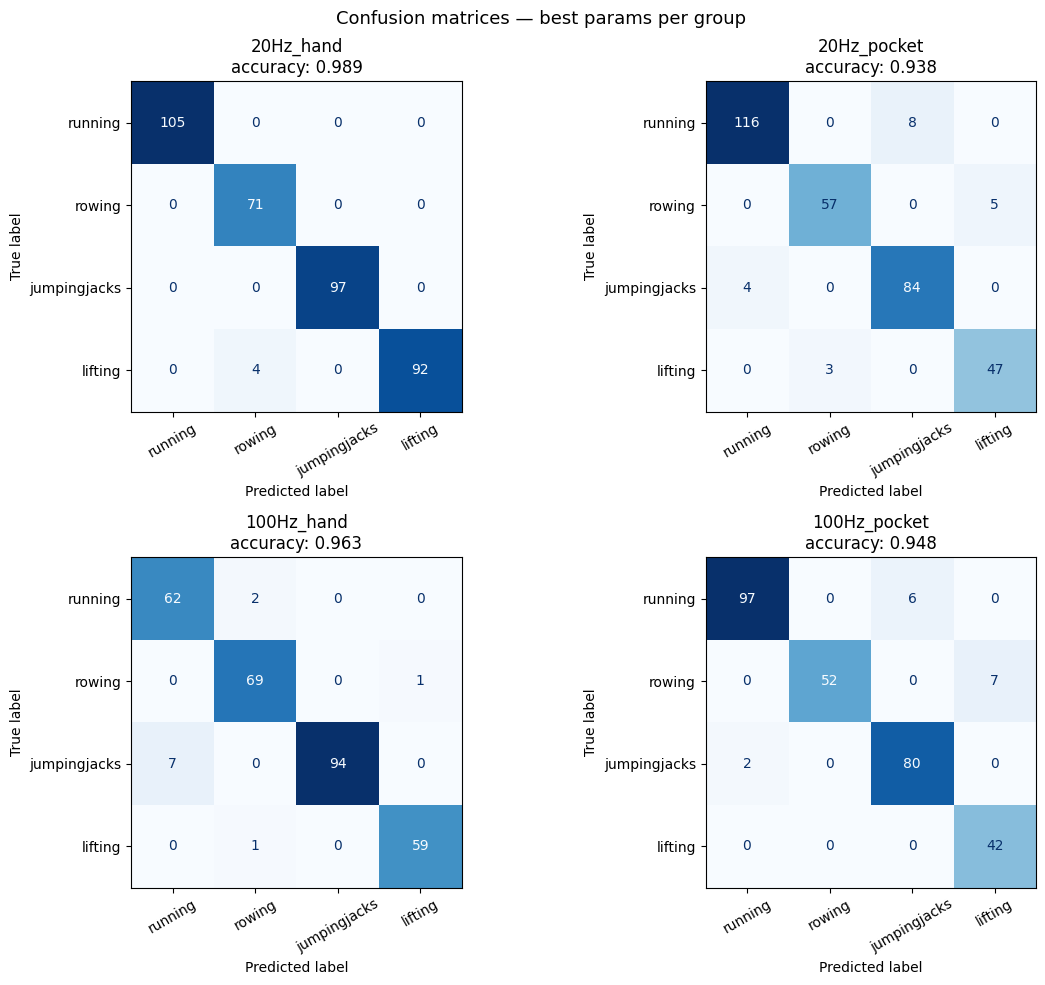

In [ ]:
activity_names = ['running', 'rowing', 'jumpingjacks', 'lifting']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (key, split) in zip(axes, splits.items()):
    X_train = split['train'].drop(columns=['activity_label'])
    y_train = split['train']['activity_label']
    X_test  = split['test'].drop(columns=['activity_label'])
    y_test  = split['test']['activity_label']

    # extract best params for this group
    p = grid_results[key]['best_params']

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", OneVsOneClassifier(SVC(
            C=p['clf__estimator__C'],
            gamma=p['clf__estimator__gamma'],
            kernel=p['clf__estimator__kernel']
        )))
    ])
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=activity_names)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{key}\naccuracy: {acc:.3f}')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion matrices — best params per group', fontsize=13)
plt.tight_layout()
plt.show()

**Results:**

All four groups achieve strong accuracy (0.938–0.989). The most common confusions are:

- **lifting ↔ rowing**: lifting gets misclassified as rowing across multiple groups, which aligns with our earlier concern that these two activities share similar intensity levels.
- **jumping jacks ↔ running**: present in the 100Hz groups, likely because both are high-impact activities with similar accelerometer magnitudes.
- **`20Hz_hand`** is the cleanest matrix overall (0.989), with only 4 lifting windows misclassified as rowing.
- **`20Hz_pocket`** shows the most spread confusion, with errors across running, jumping jacks, and rowing.

## Model export


We train one final model per group using the best parameters found by GridSearch, on the same 80/20 split used throughout. We keep all four groups (both sampling frequencies and both placements) since all achieved strong accuracy. 

We give the user the option the to choose their phone placement and sampling frequency before starting. The corresponding model is then loaded for classification.

The models are saved to disk using `joblib` and loaded directly by the app at startup.

Note: exporting and loading pre-trained models is the standard approach to avoid retraining at runtime. However, the assignment requires the model to be trained when the fitness trainer starts, so our final app does that instead. We keep this section here as a reference since it is a common pattern in practice.

In [ ]:
os.makedirs('models_2', exist_ok=True)


for key, split in splits.items():
    X_train = split['train'].drop(columns=['activity_label'])
    y_train = split['train']['activity_label']
    X_test = split['test'].drop(columns=['activity_label'])
    y_test = split['test']['activity_label']

    # extract best params for this group
    p = grid_results[key]['best_params']

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", OneVsRestClassifier(SVC(
            C=p['clf__estimator__C'],
            gamma=p['clf__estimator__gamma'],
            kernel=p['clf__estimator__kernel'],
            probability=True  # for using a threshold on prediction confidence later
        )))
    ])

    model.fit(X_train, y_train)

    model_filename = f'models/{key}_svm_model.joblib'
    joblib.dump(model, model_filename)
    print(f'Exported {model_filename} | C={p["clf__estimator__C"]}, '
          f'gamma={p["clf__estimator__gamma"]}, kernel={p["clf__estimator__kernel"]}')

Exported models_2/20Hz_hand_svm_model.joblib | C=10, gamma=scale, kernel=rbf
Exported models_2/20Hz_pocket_svm_model.joblib | C=10, gamma=0.01, kernel=rbf
Exported models_2/100Hz_hand_svm_model.joblib | C=10, gamma=scale, kernel=rbf
Exported models_2/100Hz_pocket_svm_model.joblib | C=10, gamma=scale, kernel=rbf


### Quick test to check if we can use saved models 


We verify that the exported models can be loaded and produce the same accuracy as during training. We also confirm that `predict_proba` works correctly, since we rely on it in the app to threshold prediction confidence and avoid classifying ambiguous windows.

In [ ]:
models = {
    '20Hz_hand': None,
    '20Hz_pocket' : None,
    '100Hz_hand': None,
    '100Hz_pocket': None
}

In [ ]:
imported_models = {}
for key in models.keys():
    model_filename = f'models_2/{key}_svm_model.joblib'
    imported_models[key] = joblib.load(model_filename)

In [ ]:
# verify accuracy on the held-out test sets
for key, split in splits.items():
    X_test = split['test'].drop(columns=['activity_label'])
    y_test = split['test']['activity_label']

    model = imported_models[key]
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f'{key} - Imported Model Accuracy: {acc:.3f}')
    proba = model.predict_proba(X_test)
    print(f'{key} - proba shape: {proba.shape}, classes: {model.classes_}')

20Hz_hand - Imported Model Accuracy: 0.986
20Hz_hand - proba shape: (369, 4), classes: [0 1 2 3]
20Hz_pocket - Imported Model Accuracy: 0.938
20Hz_pocket - proba shape: (324, 4), classes: [0 1 2 3]
100Hz_hand - Imported Model Accuracy: 0.956
100Hz_hand - proba shape: (295, 4), classes: [0 1 2 3]
100Hz_pocket - Imported Model Accuracy: 0.944
100Hz_pocket - proba shape: (286, 4), classes: [0 1 2 3]
